# QM640 Food Price Affordability AI
## Notebook 05 — Synopsis-Aligned Forecasting Models

**RQ2:** Do machine-learning and ensemble models predict essential-food prices
more accurately than conventional statistical forecasting models?

Exact 1-, 2-, and 3-month state–commodity targets are evaluated through
expanding chronological origins. A separate damped-ETS national CPI path
preserves the requested 24-month planning forecast.


## 1. Setup and inputs


In [ ]:
from pathlib import Path
import json, os, warnings, time
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.holtwinters import ExponentialSmoothing
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

state = pd.read_csv(PROCESSED / "cleaned_state_monthly.csv.gz", parse_dates=["date"], low_memory=False)
national = pd.read_csv(PROCESSED / "cleaned_national_monthly.csv.gz", parse_dates=["date"], low_memory=False)
nb04 = json.loads((REPORT_OUTPUT / "04_execution_summary.json").read_text(encoding="utf-8"))
print(f"State rows: {len(state):,}; national rows: {len(national):,}")


Mounted at /content/drive
State rows: 41,792; national rows: 319


## 2. Features, exact seasonal baseline, and rolling origins


In [ ]:
TARGETS = {1: "future_price_change_h1m_pct", 2: "future_price_change_h2m_pct", 3: "future_price_change_h3m_pct"}
numeric_features = [
    "price_mom_pct", "price_yoy_pct", "rainfall_anomaly_pct",
    "temperature_anomaly_c", "relative_humidity_pct",
    "production_tonne", "yield_kg_per_hectare",
    "rural_wage_rs_per_day", "source_rows",
]
numeric_features = [c for c in numeric_features if c in state.columns]
categorical_features = ["region", "Commodity", "month"]
data = state.copy()
data["month"] = data["date"].dt.month.astype(str)

# Exact 12-month target lag supplies a conventional seasonal-change baseline.
for horizon, target in TARGETS.items():
    lag = data[["region", "Commodity", "date", target]].copy()
    lag["date"] = lag["date"] + pd.DateOffset(months=12)
    lag = lag.rename(columns={target: f"seasonal_target_h{horizon}"})
    data = data.merge(lag, on=["region", "Commodity", "date"], how="left", validate="one_to_one")

last_usable = min(
    data.loc[data[target].notna(), "date"].max() for target in TARGETS.values()
)
candidate_origins = pd.date_range(end=last_usable, periods=24, freq="MS")
origin_dates = list(candidate_origins[::3])  # eight quarterly-spaced rolling origins
print("Rolling origins:", [str(x.date()) for x in origin_dates])


Rolling origins: ['2024-05-01', '2024-08-01', '2024-11-01', '2025-02-01', '2025-05-01', '2025-08-01', '2025-11-01', '2026-02-01']


## 3. Chronological model comparison


In [ ]:
ridge_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
tree_preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
])

def model_factories():
    return {
        "ridge": lambda: Pipeline([
            ("prep", ridge_preprocessor),
            ("model", Ridge(alpha=10.0)),
        ]),
        "hist_gradient_boosting": lambda: Pipeline([
            ("prep", tree_preprocessor),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.05, max_iter=160, max_leaf_nodes=20,
                min_samples_leaf=30, l2_regularization=1.0, random_state=640
            )),
        ]),
    }

prediction_rows = []
start_time = time.time()
feature_columns = numeric_features + categorical_features
for horizon, target in TARGETS.items():
    seasonal_column = f"seasonal_target_h{horizon}"
    for origin in origin_dates:
        train = data.loc[data["date"].lt(origin) & data[target].notna()].copy()
        test = data.loc[data["date"].eq(origin) & data[target].notna()].copy()
        if len(train) < 1000 or len(test) == 0:
            continue
        actual = test[target].to_numpy()
        baselines = {
            "zero_change": np.zeros(len(test)),
            "seasonal_change": test[seasonal_column].fillna(0).to_numpy(),
        }
        for model_name, pred in baselines.items():
            for idx, value in enumerate(pred):
                prediction_rows.append({
                    "horizon_months": horizon, "origin": origin,
                    "region": str(test.iloc[idx]["region"]),
                    "Commodity": str(test.iloc[idx]["Commodity"]),
                    "model": model_name, "actual": float(actual[idx]), "forecast": float(value),
                })
        for model_name, factory in model_factories().items():
            model = factory()
            model.fit(train[feature_columns], train[target])
            pred = model.predict(test[feature_columns])
            for idx, value in enumerate(pred):
                prediction_rows.append({
                    "horizon_months": horizon, "origin": origin,
                    "region": str(test.iloc[idx]["region"]),
                    "Commodity": str(test.iloc[idx]["Commodity"]),
                    "model": model_name, "actual": float(actual[idx]), "forecast": float(value),
                })
    print(f"Completed horizon {horizon}/3")

predictions = pd.DataFrame(prediction_rows)
predictions["error"] = predictions["actual"] - predictions["forecast"]
predictions["absolute_error"] = predictions["error"].abs()
predictions["squared_error"] = predictions["error"] ** 2
predictions["direction_correct"] = (
    np.sign(predictions["actual"]) == np.sign(predictions["forecast"])
)
metrics = (
    predictions.groupby(["horizon_months", "model"], as_index=False)
    .agg(
        n_forecasts=("actual", "size"),
        mae=("absolute_error", "mean"),
        mse=("squared_error", "mean"),
        mean_error_bias=("error", "mean"),
        directional_accuracy=("direction_correct", "mean"),
    )
)
metrics["rmse"] = np.sqrt(metrics.pop("mse"))
metrics = metrics.sort_values(["horizon_months", "rmse"])
predictions.to_csv(REPORT_OUTPUT / "05_panel_rolling_predictions.csv.gz", index=False, compression="gzip")
metrics.to_csv(REPORT_OUTPUT / "05_panel_model_metrics.csv", index=False)
print(metrics.round(4).to_string(index=False))
print(f"Elapsed: {time.time() - start_time:.1f} seconds")


Completed horizon 1/3
Completed horizon 2/3
Completed horizon 3/3
 horizon_months                  model  n_forecasts     mae  mean_error_bias  directional_accuracy     rmse
              1 hist_gradient_boosting         1054 18.6561           0.2102                0.5778 126.7894
              1                  ridge         1054 18.4685           2.2921                0.5825 129.2542
              1            zero_change         1054 16.4124           5.4608                0.0076 131.5756
              1        seasonal_change         1054 19.9947           3.0192                0.5626 132.8155
              2 hist_gradient_boosting         1040 20.9893          -8.3510                0.5894  35.8110
              2                  ridge         1040 24.5836          -5.2831                0.5644  36.5288
              2            zero_change         1040 21.7446           5.2297                0.0067  40.3167
              2        seasonal_change         1040 32.5436         -1

## 4. RQ2 paired hypothesis tests


In [ ]:
test_rows = []
selected_models = {}
for horizon in TARGETS:
    horizon_metrics = metrics.loc[metrics["horizon_months"].eq(horizon)]
    baseline_names = ["zero_change", "seasonal_change"]
    ml_names = ["ridge", "hist_gradient_boosting"]
    best_baseline = horizon_metrics.loc[
        horizon_metrics["model"].isin(baseline_names)
    ].sort_values("rmse").iloc[0]["model"]
    best_ml = horizon_metrics.loc[
        horizon_metrics["model"].isin(ml_names)
    ].sort_values("rmse").iloc[0]["model"]
    selected_models[horizon] = str(
        horizon_metrics.sort_values("rmse").iloc[0]["model"]
    )
    left = predictions.loc[
        (predictions["horizon_months"] == horizon) & (predictions["model"] == best_ml),
        ["origin", "region", "Commodity", "absolute_error"],
    ].rename(columns={"absolute_error": "ml_absolute_error"})
    right = predictions.loc[
        (predictions["horizon_months"] == horizon) & (predictions["model"] == best_baseline),
        ["origin", "region", "Commodity", "absolute_error"],
    ].rename(columns={"absolute_error": "baseline_absolute_error"})
    paired = left.merge(right, on=["origin", "region", "Commodity"], validate="one_to_one")
    statistic, p_value = wilcoxon(
        paired["ml_absolute_error"], paired["baseline_absolute_error"],
        alternative="less", zero_method="zsplit"
    )
    ml_rmse = float(horizon_metrics.loc[horizon_metrics["model"].eq(best_ml), "rmse"].iloc[0])
    baseline_rmse = float(horizon_metrics.loc[horizon_metrics["model"].eq(best_baseline), "rmse"].iloc[0])
    test_rows.append({
        "horizon_months": horizon,
        "best_ml_model": best_ml,
        "best_statistical_baseline": best_baseline,
        "paired_forecasts": int(len(paired)),
        "ml_rmse": ml_rmse,
        "baseline_rmse": baseline_rmse,
        "rmse_improvement_pct": (baseline_rmse - ml_rmse) / baseline_rmse * 100,
        "wilcoxon_statistic": float(statistic),
        "one_sided_p_value": float(p_value),
    })
hypothesis_tests = pd.DataFrame(test_rows)
hypothesis_tests["p_value_holm"] = multipletests(
    hypothesis_tests["one_sided_p_value"], alpha=0.05, method="holm"
)[1]
hypothesis_tests["decision_h0_2"] = np.where(
    (hypothesis_tests["p_value_holm"] < 0.05) &
    (hypothesis_tests["rmse_improvement_pct"] > 0),
    "reject_H0_2_ML_lower_loss",
    "fail_to_reject_H0_2",
)
hypothesis_tests.to_csv(REPORT_OUTPUT / "05_rq2_hypothesis_tests.csv", index=False)
print(hypothesis_tests.round(5).to_string(index=False))


 horizon_months          best_ml_model best_statistical_baseline  paired_forecasts   ml_rmse  baseline_rmse  rmse_improvement_pct  wilcoxon_statistic  one_sided_p_value  p_value_holm       decision_h0_2
              1 hist_gradient_boosting               zero_change              1054 126.78942      131.57560               3.63759            292445.5            0.92814           1.0 fail_to_reject_H0_2
              2 hist_gradient_boosting               zero_change              1040  35.81098       40.31668              11.17578            276629.0            0.73108           1.0 fail_to_reject_H0_2
              3 hist_gradient_boosting               zero_change              1041  34.75528       46.28206              24.90550            270600.0            0.47615           1.0 fail_to_reject_H0_2


## 5. Requested 24-month national food-CPI planning forecast


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


      date  horizon_months  forecast  lower_95_approx  upper_95_approx                                                           assumption
2026-01-01               1   158.014          156.114          159.914 Damped ETS conditional planning path; approximate expanding interval
2026-02-01               2   157.635          154.949          160.322 Damped ETS conditional planning path; approximate expanding interval
2026-03-01               3   157.736          154.445          161.027 Damped ETS conditional planning path; approximate expanding interval
2026-04-01               4   158.454          154.654          162.254 Damped ETS conditional planning path; approximate expanding interval
2026-05-01               5   159.056          154.808          163.304 Damped ETS conditional planning path; approximate expanding interval
2026-06-01               6   160.212          155.558          164.866 Damped ETS conditional planning path; approximate expanding interval
2026-07-01          

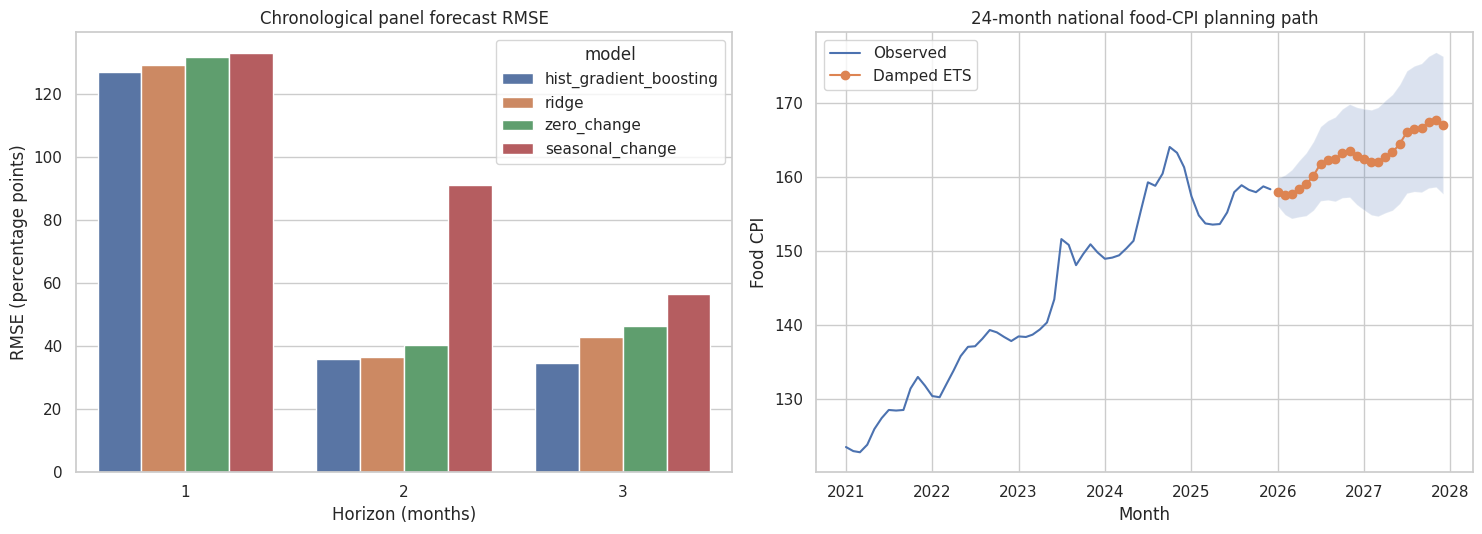

In [ ]:
cpi = (
    national[["date", "food_cpi_2015_100"]]
    .dropna().sort_values("date").set_index("date")["food_cpi_2015_100"]
)
ets = ExponentialSmoothing(
    cpi, trend="add", damped_trend=True, seasonal="add",
    seasonal_periods=12, initialization_method="estimated"
).fit(optimized=True, remove_bias=True)
forecast_dates = pd.date_range(cpi.index.max() + pd.offsets.MonthBegin(1), periods=24, freq="MS")
forecast_values = np.asarray(ets.forecast(24))
residual_sd = float(np.std(ets.resid, ddof=1))
horizon_scale = np.sqrt(np.arange(1, 25))
forward = pd.DataFrame({
    "date": forecast_dates,
    "horizon_months": np.arange(1, 25),
    "forecast": forecast_values,
    "lower_95_approx": forecast_values - 1.96 * residual_sd * horizon_scale,
    "upper_95_approx": forecast_values + 1.96 * residual_sd * horizon_scale,
    "assumption": "Damped ETS conditional planning path; approximate expanding interval",
})
forward.to_csv(REPORT_OUTPUT / "05_national_24_month_forecast.csv", index=False)
print(forward.round(3).to_string(index=False))

if not SKIP_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.barplot(data=metrics, x="horizon_months", y="rmse", hue="model", ax=axes[0])
    axes[0].set(title="Chronological panel forecast RMSE", xlabel="Horizon (months)", ylabel="RMSE (percentage points)")
    axes[1].plot(cpi.index[-60:], cpi.iloc[-60:], label="Observed")
    axes[1].plot(forward["date"], forward["forecast"], marker="o", label="Damped ETS")
    axes[1].fill_between(forward["date"], forward["lower_95_approx"], forward["upper_95_approx"], alpha=0.2)
    axes[1].set(title="24-month national food-CPI planning path", xlabel="Month", ylabel="Food CPI")
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "05_aligned_forecasting_results.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary


In [ ]:
summary = {
    "notebook": "05_forecasting_models_synopsis_aligned",
    "status": "completed",
    "original_research_question_preserved": True,
    "dependent_variable_horizons_months": [1, 2, 3],
    "rolling_origins": len(origin_dates),
    "evaluation_start": str(min(origin_dates).date()),
    "evaluation_end": str(max(origin_dates).date()),
    "models_compared": metrics["model"].unique().tolist(),
    "selected_models_by_horizon": {f"{h}_month": m for h, m in selected_models.items()},
    "rq2_hypothesis_decisions": {
        f"{int(row.horizon_months)}_month": row.decision_h0_2
        for row in hypothesis_tests.itertuples()
    },
    "holm_adjusted_p_values": {
        f"{int(row.horizon_months)}_month": float(row.p_value_holm)
        for row in hypothesis_tests.itertuples()
    },
    "panel_forecasts_evaluated": int(len(predictions)),
    "national_forecast_model": "damped_ets",
    "national_forecast_horizon_months": 24,
    "national_forecast_start": str(forward["date"].min().date()),
    "national_forecast_end": str(forward["date"].max().date()),
    "interpretation": "Chronologically validated prediction; not causal.",
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "05_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")
expected = [
    REPORT_OUTPUT / "05_panel_rolling_predictions.csv.gz",
    REPORT_OUTPUT / "05_panel_model_metrics.csv",
    REPORT_OUTPUT / "05_rq2_hypothesis_tests.csv",
    REPORT_OUTPUT / "05_national_24_month_forecast.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS: expected.append(FIGURES / "05_aligned_forecasting_results.png")
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 05 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 05 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "05_forecasting_models_synopsis_aligned",
  "status": "completed",
  "original_research_question_preserved": true,
  "dependent_variable_horizons_months": [
    1,
    2,
    3
  ],
  "rolling_origins": 8,
  "evaluation_start": "2024-05-01",
  "evaluation_end": "2026-02-01",
  "models_compared": [
    "hist_gradient_boosting",
    "ridge",
    "zero_change",
    "seasonal_change"
  ],
  "selected_models_by_horizon": {
    "1_month": "hist_gradient_boosting",
    "2_month": "hist_gradient_boosting",
    "3_month": "hist_gradient_boosting"
  },
  "rq2_hypothesis_decisions": {
    "1_month": "fail_to_reject_H0_2",
    "2_month": "fail_to_reject_H0_2",
    "3_month": "fail_to_reject_H0_2"
  },
  "holm_adjusted_p_values": {
    "1_month": 1.0,
    "2_month": 1.0,
    "3_month": 1.0
  },
  "panel_forecasts_evaluated": 12540,
  "national_forecast_model": "damped_ets",
  "national_forecast_horizon_months": 24,
  "

## Notebook 05 conclusion

RQ2 is assessed separately at each exact horizon using paired chronological
errors and Holm adjustment. The 24-month national CPI forecast is a conditional
planning path, not a causal projection or guaranteed outcome.
